##Model Training

In [ ]:
#!pip install catboost

## 1.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [ ]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

##Import the CSV Data as Pandas DataFrame

In [ ]:
df = pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\ML\Data\insurance.csv')

##Show Top 5 Records

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Preparing X and Y variables

In [ ]:
X = df.drop(columns=['charges'],axis=1)

In [ ]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [ ]:
print("Categories in 'sex' variable:     ",end=" " )
print(df['sex'].unique())

print("Categories in 'region' variable:  ",end=" ")
print(df['region'].unique())

print("Categories in'smoker' variable:",end=" " )
print(df['smoker'].unique())

Categories in 'sex' variable:      ['female' 'male']
Categories in 'region' variable:   ['southwest' 'southeast' 'northwest' 'northeast']
Categories in'smoker' variable: ['yes' 'no']


In [ ]:
y = df['charges']

In [ ]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [ ]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [ ]:
X = preprocessor.fit_transform(X)

In [ ]:
X

array([[ 1.        ,  0.        ,  0.        , ..., -1.43876426,
        -0.45332   , -0.90861367],
       [ 0.        ,  1.        ,  1.        , ..., -1.50996545,
         0.5096211 , -0.07876719],
       [ 0.        ,  1.        ,  1.        , ..., -0.79795355,
         0.38330685,  1.58092576],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -1.50996545,
         1.0148781 , -0.90861367],
       [ 1.        ,  0.        ,  1.        , ..., -1.29636188,
        -0.79781341, -0.90861367],
       [ 1.        ,  0.        ,  0.        , ...,  1.55168573,
        -0.26138796, -0.90861367]], shape=(1338, 11))

In [ ]:
X.shape

(1338, 11)

In [ ]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1070, 11), (268, 11))

##Create an Evaluate Function to give all metrics after model Training


In [ ]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}


In [ ]:
list(models)

['Linear Regression',
 'K-Neighbors Regressor',
 'Decision Tree',
 'Random Forest Regressor',
 'XGBRegressor',
 'CatBoosting Regressor',
 'AdaBoost Regressor']

In [ ]:
len(list(models))

7

In [ ]:
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 6105.5452
- Mean Absolute Error: 4208.2346
- R2 Score: 0.7417
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5796.2847
- Mean Absolute Error: 4181.1945
- R2 Score: 0.7836


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 4772.3523
- Mean Absolute Error: 2855.8264
- R2 Score: 0.8422
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6043.4342
- Mean Absolute Error: 3672.8683
- R2 Score: 0.7647


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 494.2060
- Mean Absolute Error: 29.5725
- R2 Score: 0.9983
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6428.2225
- Mean Absolute Error: 3068.0754
- R2 Score: 0.7338


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 1906.4524
- Mean Abs

## Results

In [ ]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
5,CatBoosting Regressor,0.865093
3,Random Forest Regressor,0.863437
4,XGBRegressor,0.848485
6,AdaBoost Regressor,0.812824
0,Linear Regression,0.783593
1,K-Neighbors Regressor,0.764745
2,Decision Tree,0.733833


## CATBOOST REGRESSOR

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(columns=['charges'],axis=1)

y = df['charges']
# categorical columns (string / object type)
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CatBoost Regressor
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

# fit model (encoding yahi hoti hai internally)
cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

# prediction
y_pred = cat_model.predict(X_test)

# evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))


0:	learn: 11577.3676521	test: 12026.7629232	best: 12026.7629232 (0)	total: 9.54ms	remaining: 4.76s
100:	learn: 4328.4329445	test: 4331.5772978	best: 4331.5719760 (99)	total: 2.48s	remaining: 9.81s
200:	learn: 4074.0046823	test: 4282.5401807	best: 4279.4419739 (185)	total: 5.13s	remaining: 7.63s
300:	learn: 3871.1947879	test: 4284.8266767	best: 4276.4629512 (216)	total: 8s	remaining: 5.29s
400:	learn: 3660.3893317	test: 4288.6178522	best: 4275.7279446 (351)	total: 11s	remaining: 2.71s
499:	learn: 3513.2948422	test: 4306.1674556	best: 4275.7279446 (351)	total: 14.1s	remaining: 0us

bestTest = 4275.727945
bestIteration = 351

Shrink model to first 352 iterations.
R2 Score: 0.8822415537845539
RMSE: 18281849.39739023


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# convert to numpy arrays (safety)
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# residuals
residuals = y_test_np - y_pred_np

# IQR calculation
Q1 = np.percentile(residuals, 25)
Q3 = np.percentile(residuals, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# mask to remove outliers
mask = (residuals >= lower_bound) & (residuals <= upper_bound)

# filtered values
y_test_clean = y_test_np[mask]
y_pred_clean = y_pred_np[mask]


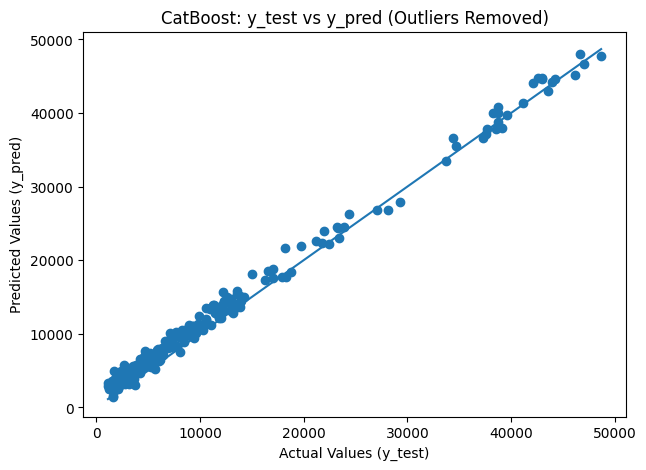

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_clean, y_pred_clean)
plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()]
)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("CatBoost: y_test vs y_pred (Outliers Removed)")
plt.show()


Insight :

Diagonal line = perfect prediction

Points line ke paas = good model performance

Outliers remove karne ke baad:

Scatter tight ho jata hai

Prediction trend zyada clear dikhta hai

Model evaluation visually better hota hai

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Encoding (Label Encoding)
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
# Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# Prediction & Evaluation
y_pred = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8661585084295524
RMSE: 20778721.78727888


In [ ]:
# convert to numpy
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# residuals
residuals = y_test_np - y_pred_np

# IQR
Q1 = np.percentile(residuals, 25)
Q3 = np.percentile(residuals, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (residuals >= lower) & (residuals <= upper)

# filtered values
y_test_clean = y_test_np[mask]
y_pred_clean = y_pred_np[mask]


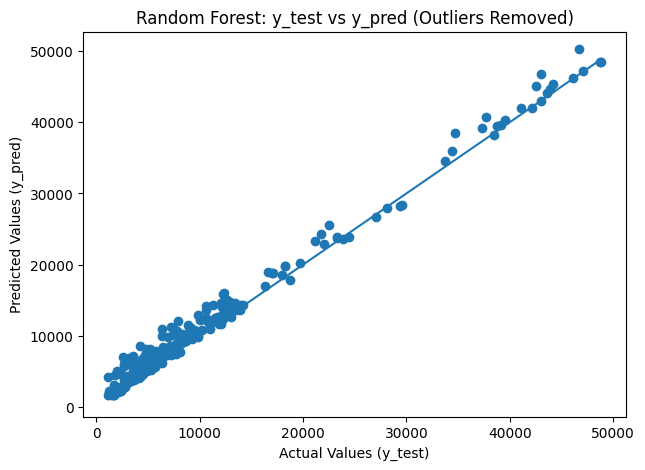

In [ ]:
# Plot y_test vs y_pred (After Outlier Removal)
plt.figure(figsize=(7, 5))
plt.scatter(y_test_clean, y_pred_clean)
plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()]
)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Random Forest: y_test vs y_pred (Outliers Removed)")
plt.show()

##**LINEAR REGRESSION**

In [ ]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 78.33


BEFORE - Outliers Removal


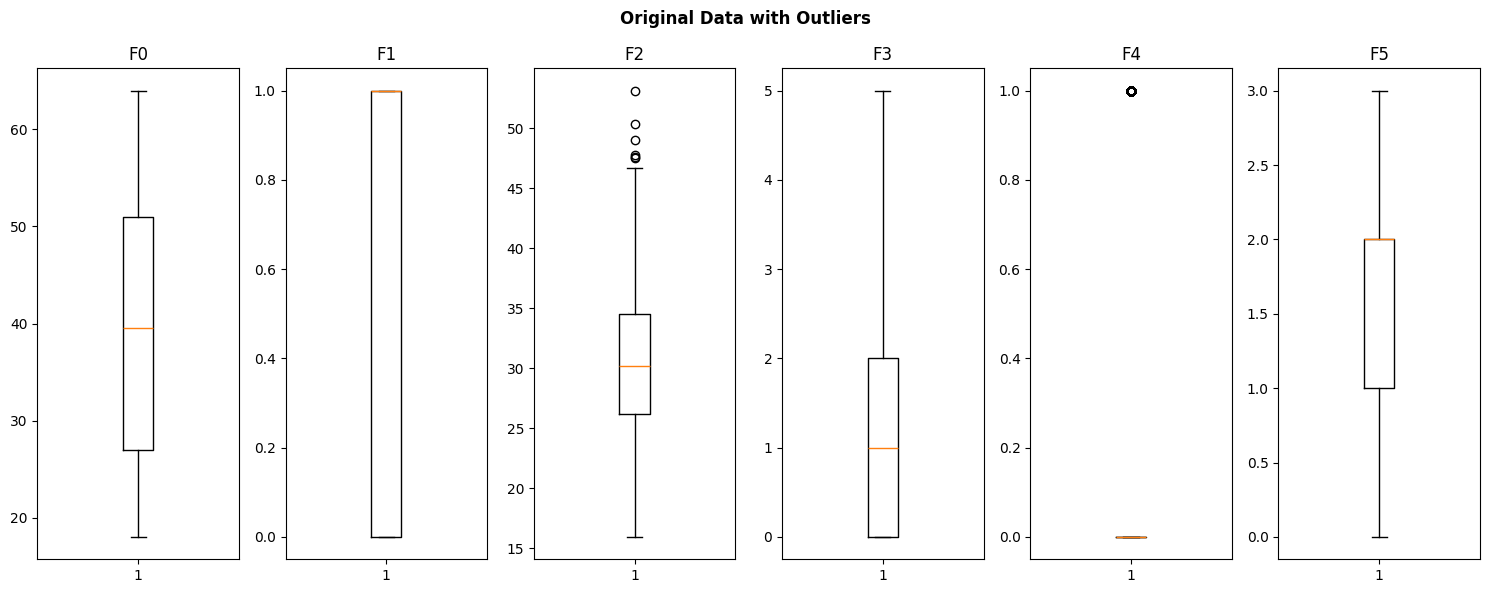

In [ ]:
import matplotlib.pyplot as plt

print("BEFORE - Outliers Removal")
plt.figure(figsize=(15, 6))

# Loop through first 6 features or total features if less than 6
num_features = min(6, X_train.shape[1])

for i in range(num_features):
    plt.subplot(1, num_features, i + 1)

    # If X_train is a DataFrame
    if hasattr(X_train, 'iloc'):
        plt.boxplot(X_train.iloc[:, i])
    else:  # If X_train is a NumPy array
        plt.boxplot(X_train[:, i])

    plt.title(f'F{i}')

plt.suptitle('Original Data with Outliers', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Remove outlier

Q1 = np.percentile(X_train, 25, axis=0)
Q3 = np.percentile(X_train, 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask_train = np.all((X_train >= lower_bound) & (X_train <= upper_bound), axis=1)
mask_test = np.all((X_test >= lower_bound) & (X_test <= upper_bound), axis=1)

# Clean datasets
X_train_clean = X_train[mask_train]
y_train_clean = y_train[mask_train]
X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]

print(f"Training: {X_train.shape[0]} → {X_train_clean.shape[0]} ({100*(1-X_train_clean.shape[0]/X_train.shape[0]):.1f}% removed)")
print(f"Test:    {X_test.shape[0]} → {X_test_clean.shape[0]} ({100*(1-X_test_clean.shape[0]/X_test.shape[0]):.1f}% removed)")


Training: 1070 → 845 (21.0% removed)
Test:    268 → 213 (20.5% removed)


In [ ]:
print(type(X_train_clean))
print(X_train_clean.shape)


<class 'pandas.core.frame.DataFrame'>
(845, 6)


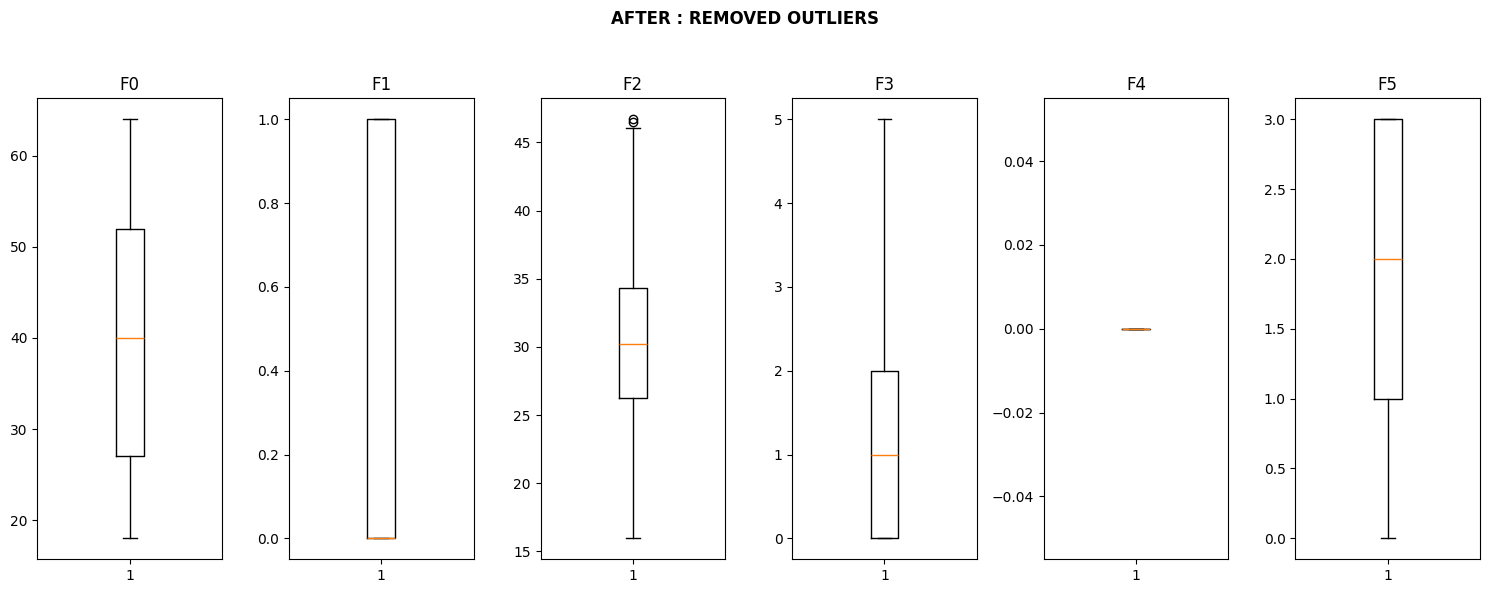

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to NumPy array if it's a DataFrame
if not isinstance(X_train_clean, np.ndarray):
    X_plot = X_train_clean.values
else:
    X_plot = X_train_clean

plt.figure(figsize=(15, 6))

n_features = min(6, X_plot.shape[1])

for i in range(n_features):
    plt.subplot(1, n_features, i + 1)
    plt.boxplot(X_plot[:, i])
    plt.title(f'F{i}')

plt.suptitle('AFTER : REMOVED OUTLIERS', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## After outlier remove Linear Regressor


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Model initialization
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_clean, y_train_clean)

# Prediction
y_pred_clean = lr_model.predict(X_test_clean)

# R2 Score (Accuracy)
score = r2_score(y_test_clean, y_pred_clean) * 100
print("Accuracy of the model is %.2f" % score)


Accuracy of the model is 45.75


## Plot y_pred and y_test

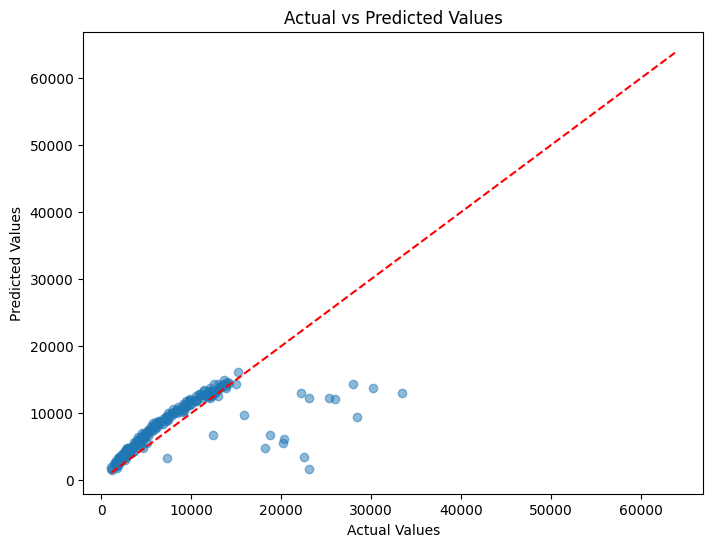

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_clean, y_pred_clean, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

plt.show()


In [ ]:
# Residuals
residuals = y_test - y_pred


**QQ PLOT**

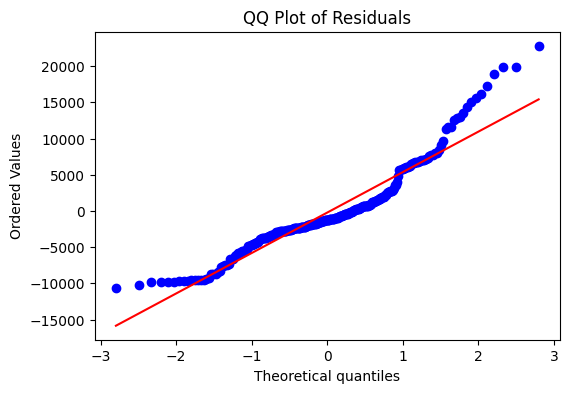

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()


Interpretation:

Points close to straight line → residuals are normally distributed

Large deviation → non-normality

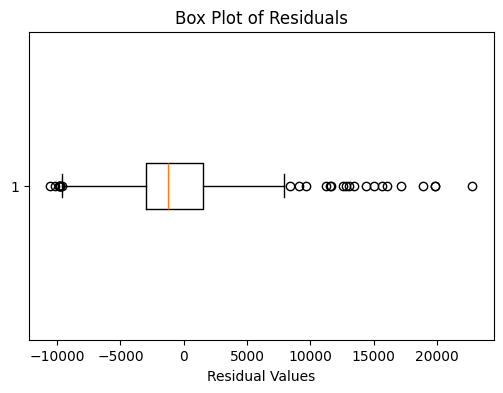

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(residuals, vert=False)
plt.title("Box Plot of Residuals")
plt.xlabel("Residual Values")
plt.show()


Interpretation:

Dots outside whiskers → outliers

Symmetric box → good model fit

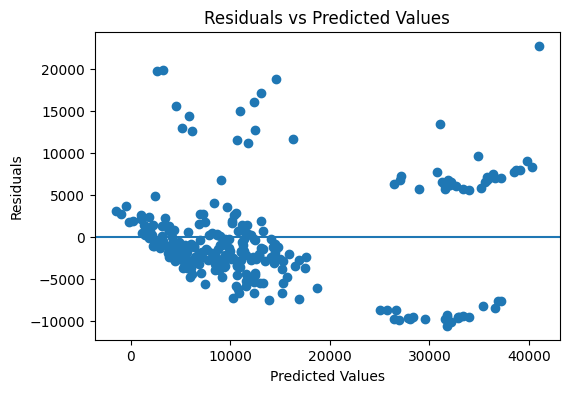

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


Interpretation:

Random scatter around zero → good model

Pattern/funnel shape → heteroscedasticity

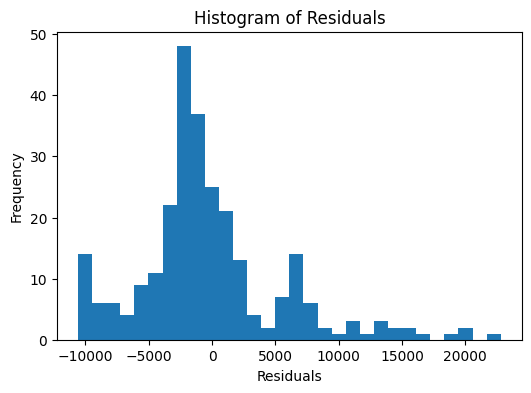

In [ ]:
# Histogram
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


Finding Outliers using IQR

In [ ]:
import numpy as np

Q1 = np.percentile(residuals, 25)
Q3 = np.percentile(residuals, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(-9632.620348099994), np.float64(8180.270861066096))

In [ ]:
# Remove Outliers
mask = (residuals >= lower_bound) & (residuals <= upper_bound)

residuals_clean = residuals[mask]
y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]

print("Original samples:", len(residuals))
print("After outlier removal:", len(residuals_clean))


Original samples: 268
After outlier removal: 241


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13552\1033903816.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([residuals, residuals_clean], labels=["Before", "After"])


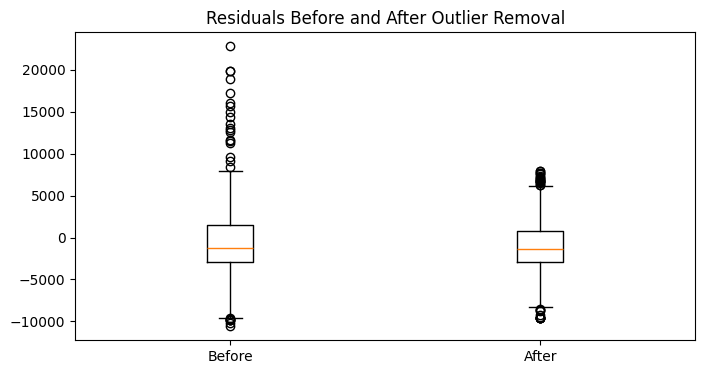

In [ ]:
# Box Plot (Before vs After)
plt.figure(figsize=(8,4))
plt.boxplot([residuals, residuals_clean], labels=["Before", "After"])
plt.title("Residuals Before and After Outlier Removal")
plt.show()

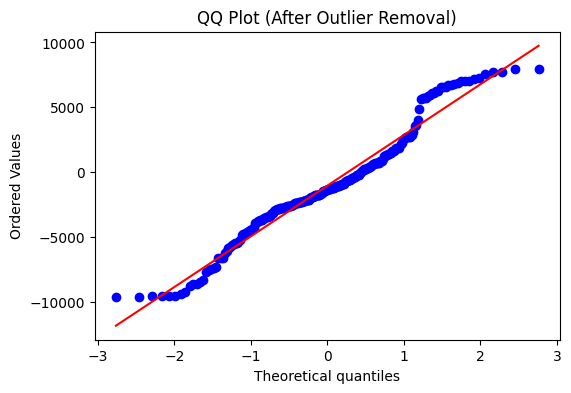

In [ ]:
# QQ Plot After Outlier Removal
import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(residuals_clean, dist="norm", plot=plt)
plt.title("QQ Plot (After Outlier Removal)")
plt.show()

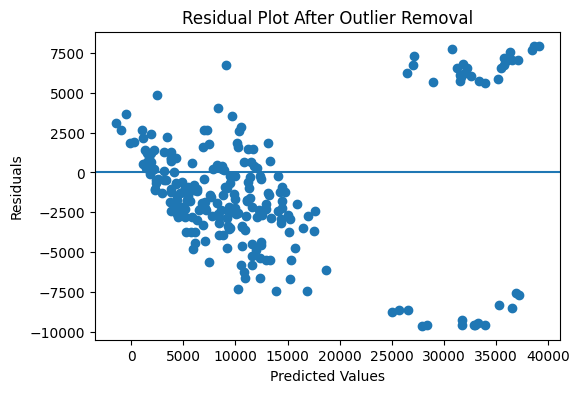

In [ ]:
# Residuals vs Predicted (After Removal)
plt.figure(figsize=(6,4))
plt.scatter(y_pred_clean, residuals_clean)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot After Outlier Removal")
plt.show()

## Difference between Actual and Predicted Values

In [ ]:
pred_df = pd.DataFrame({
    'Actual Value': y_test_clean,
    'Predicted Value': y_pred_clean,
    'Difference': y_test_clean - y_pred_clean
})

pred_df


,Actual Value,Predicted Value,Difference
764,9095.06825,8924.407244,170.661006
887,5272.17580,7116.295018,-1844.119218
890,29330.98315,36909.013521,-7578.030371
1293,9301.89355,9507.874691,-205.981141
259,33750.29180,27013.350008,6736.941792
...,...,...,...
741,18246.49550,27868.401121,-9621.905621
109,47055.53210,39116.968669,7938.563431
575,12222.89830,11814.555568,408.342732
535,6067.12675,7638.107736,-1570.980986


In [ ]:
import pickle

# 1. Select your best model (e.g., Linear Regression or Random Forest)
best_model = lin_model # Change this to whichever model performed best

# 2. Save the Preprocessor (CRITICAL: used to transform input data)
with open('preprocessor.pkl', 'wb') as file:
    pickle.dump(preprocessor, file)

# 3. Save the Model
with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Files exported successfully!")

Files exported successfully!
